# Brazilian E-Commerce — Exploratory Data Analysis
> **Dataset**: Olist Brazilian E-Commerce Public Dataset  
> **Tools**: Python · MariaDB · SQLAlchemy · Pandas · Matplotlib · Seaborn

---

## Business Questions

| # | Question | Theme |
|---|----------|-------|
| 1 | Which product categories generate the highest GMV? | Product |
| 2 | Which sellers have the highest late-delivery rate vs review score? | Logistics |
| 3 | What is the monthly revenue growth trend (MoM %)? | Revenue |
| 4 | What percentage of customers place more than one order? | Retention |
| 5 | Which states have the highest average order value? | Geography |
| 6 | What is the preferred payment method and how does installment count affect order value? | Payment |
| 7 | What is the average delivery time gap by state? | Delivery |
| 8 | Who are the top sellers by combined revenue and rating? | Sellers |

In [9]:
import sys
!"{sys.executable}" -m pip install pymysql

  Using cached pymysql-1.2.0-py3-none-any.whl.metadata (4.3 kB)
Using cached pymysql-1.2.0-py3-none-any.whl (45 kB)


In [1]:
# ── 1. IMPORTS & GLOBAL STYLE ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from getpass import getpass
import os
import warnings
warnings.filterwarnings('ignore')

# Create charts output folder
os.makedirs('charts', exist_ok=True)

# ── Color Palette ─────────────────────────────────────────────────────────────
DARK_BG   = '#1e1e2e'
SURFACE   = '#2a2a3e'
PRIMARY   = '#6C63FF'
SECONDARY = '#FF6584'
ACCENT    = '#43B89C'
ORANGE    = '#FFA07A'
YELLOW    = '#FFD166'
TEXT      = '#e0e0ff'
GRID      = '#3a3a5e'
PALETTE   = [PRIMARY, SECONDARY, ACCENT, ORANGE, YELLOW, '#87CEEB', '#FF69B4', '#98FB98']

# ── Global Matplotlib Config ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : SURFACE,
    'axes.labelcolor'  : TEXT,
    'axes.edgecolor'   : GRID,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'text.color'       : TEXT,
    'xtick.color'      : TEXT,
    'ytick.color'      : TEXT,
    'grid.color'       : GRID,
    'grid.alpha'       : 0.4,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 120,
})

print('✅ Libraries loaded & style configured!')

✅ Libraries loaded & style configured!


In [ ]:
# ── 2. DATABASE CONNECTION ────────────────────────────────────────────────────
password = getpass('Enter your MariaDB password: ')

connection_url = URL.create(
    drivername = 'mysql+pymysql',
    username   = 'root',
    password   = password,
    host       = 'localhost',
    port       = 3310,
    database   = 'brazilian e-commerce'
)

engine = create_engine(connection_url)

# Test connection
try:
    with engine.connect() as conn:
        conn.execute(text('SELECT 1'))
    print('Connected to MariaDB — Brazilian E-Commerce database!')
except Exception as e:
    print(f'Connection failed: {e}')

✅ Connected to MariaDB — Brazilian E-Commerce database!


---
## Q1 — Top 10 Product Categories by GMV vs Order Volume

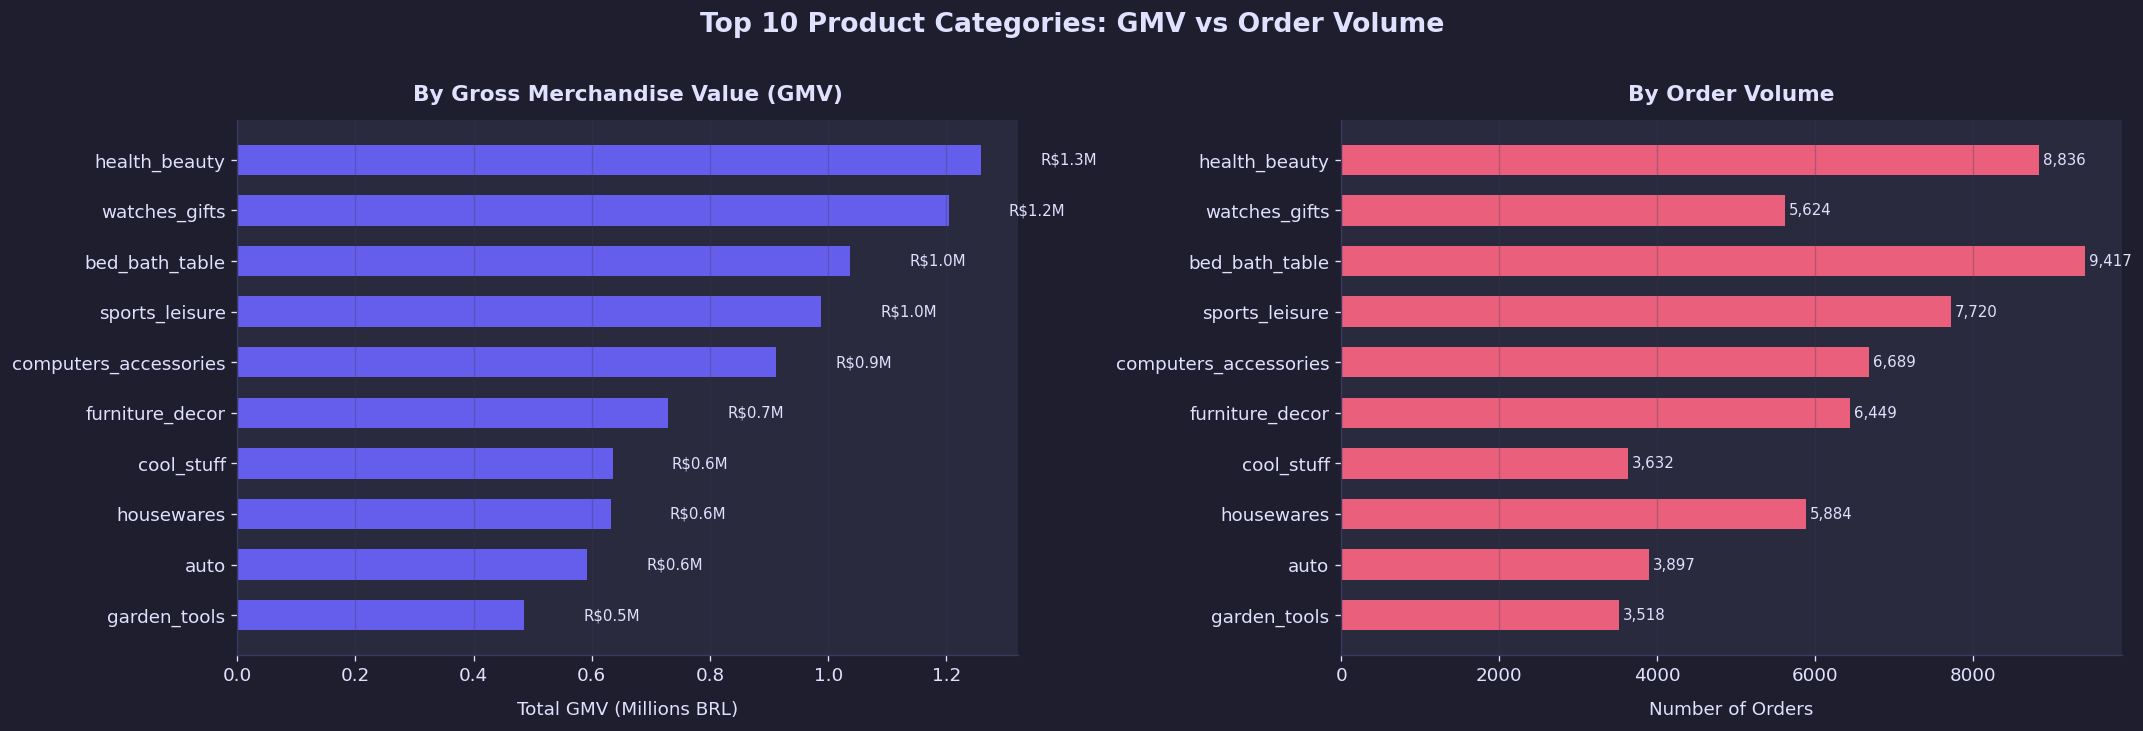


💡 Insight: 'health_beauty' leads with R$1.3M in GMV.


In [ ]:
q1 = """
SELECT 
    pcnt.product_category_name_english AS product_category,
    COUNT(DISTINCT ooid.order_id)      AS order_volume,
    ROUND(SUM(ooid.price), 2)          AS total_gmv
FROM olist_order_items_dataset ooid 
JOIN olist_products_dataset opd 
    ON ooid.product_id = opd.product_id 
JOIN product_category_name_translation pcnt 
    ON opd.product_category_name = pcnt.product_category_name
GROUP BY pcnt.product_category_name_english 
ORDER BY total_gmv DESC
LIMIT 10
"""
df_q1 = pd.read_sql(q1, engine)
df_q1 = df_q1.sort_values('total_gmv', ascending=True)  # for horizontal bars

fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=DARK_BG)
fig.suptitle('Top 10 Product Categories: GMV vs Order Volume', 
             fontsize=16, fontweight='bold', color=TEXT, y=1.01)

# — Left: GMV —
bars1 = axes[0].barh(df_q1['product_category'], df_q1['total_gmv'] / 1e6,
                     color=PRIMARY, alpha=0.9, height=0.6)
axes[0].set_xlabel('Total GMV (Millions BRL)', labelpad=10)
axes[0].set_title('By Gross Merchandise Value (GMV)', pad=12)
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars1, df_q1['total_gmv']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'R${val/1e6:.1f}M', va='center', fontsize=9, color=TEXT)

# — Right: Order Volume —
bars2 = axes[1].barh(df_q1['product_category'], df_q1['order_volume'],
                     color=SECONDARY, alpha=0.9, height=0.6)
axes[1].set_xlabel('Number of Orders', labelpad=10)
axes[1].set_title('By Order Volume', pad=12)
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, df_q1['order_volume']):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9, color=TEXT)

plt.tight_layout()
plt.savefig('charts/q1_gmv_by_category.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

top = df_q1.sort_values('total_gmv', ascending=False).iloc[0]
print(f"\nInsight: '{top['product_category']}' leads with R${top['total_gmv']/1e6:.1f}M in GMV.")

---
## Q2 — Seller Late-Delivery Rate vs Review Score

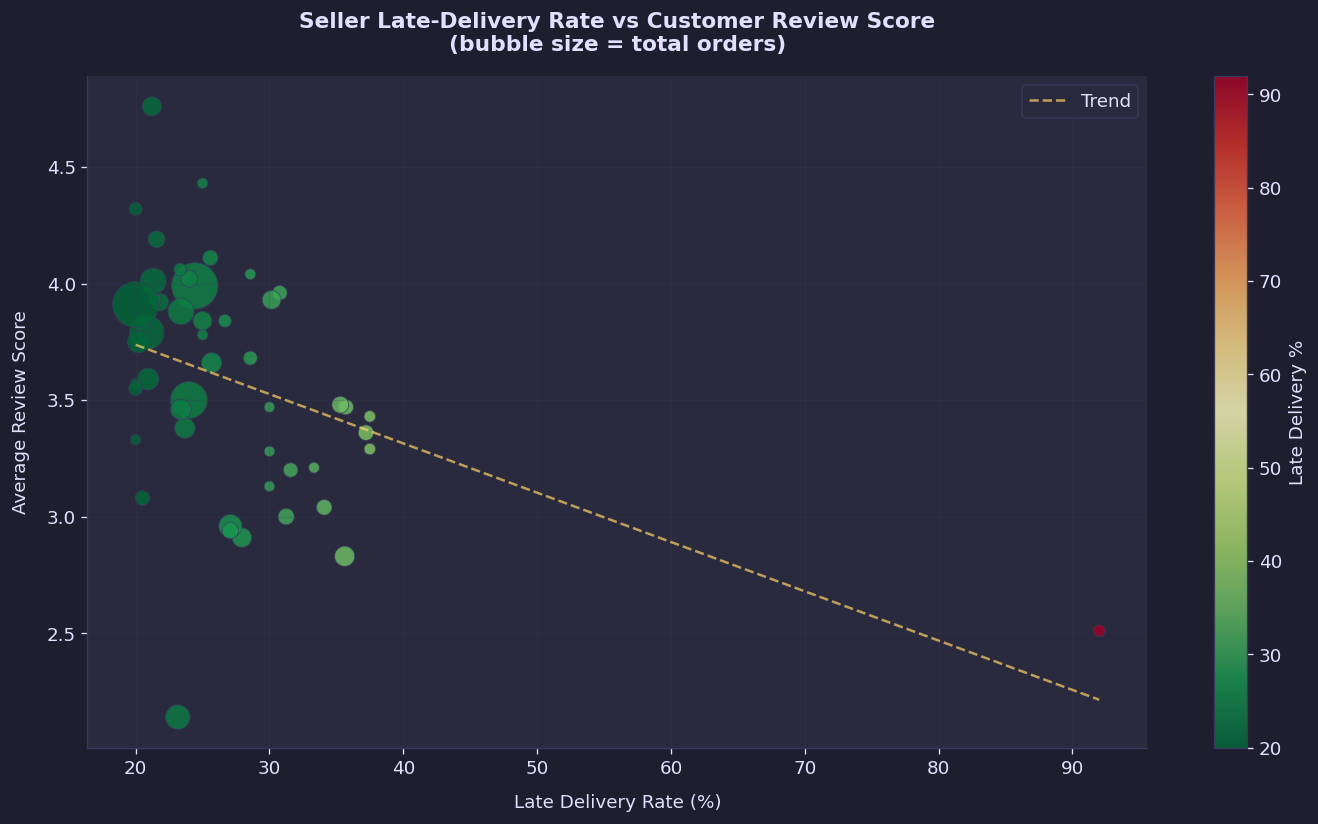


💡 Insight: Correlation between late delivery % and review score = -0.46
   Negative correlation confirms: higher late delivery → lower review scores.


In [ ]:
q2 = """
WITH seller_orders AS (
    SELECT 
        ooid.seller_id,
        ood.order_id,
        CASE WHEN ood.order_delivered_customer_date > ood.order_estimated_delivery_date
             THEN 1 ELSE 0 END AS is_late
    FROM olist_order_items_dataset ooid
    JOIN olist_orders_dataset ood ON ooid.order_id = ood.order_id
    WHERE ood.order_status = 'delivered' 
      AND ood.order_delivered_customer_date IS NOT NULL
),
seller_reviews AS (
    SELECT 
        ooid.seller_id,
        AVG(oord.review_score) AS avg_review_score 
    FROM olist_order_items_dataset ooid
    JOIN olist_order_reviews_dataset oord ON ooid.order_id = oord.order_id
    GROUP BY ooid.seller_id
)
SELECT 
    so.seller_id,
    COUNT(DISTINCT so.order_id)                                     AS total_orders, 
    SUM(so.is_late)                                                  AS late_orders,
    ROUND(SUM(so.is_late)*100 / COUNT(DISTINCT so.order_id), 2)     AS late_pct, 
    ROUND(sr.avg_review_score, 2)                                    AS avg_review
FROM seller_orders so 
JOIN seller_reviews sr ON so.seller_id = sr.seller_id
GROUP BY so.seller_id, sr.avg_review_score
HAVING COUNT(DISTINCT so.order_id) >= 20
ORDER BY late_pct DESC
LIMIT 50
"""
df_q2 = pd.read_sql(q2, engine)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=DARK_BG)
scatter = ax.scatter(
    df_q2['late_pct'], df_q2['avg_review'],
    s=df_q2['total_orders'] * 2,
    c=df_q2['late_pct'], cmap='RdYlGn_r',
    alpha=0.8, edgecolors=GRID, linewidths=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Late Delivery %', color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)

ax.set_xlabel('Late Delivery Rate (%)', labelpad=10)
ax.set_ylabel('Average Review Score', labelpad=10)
ax.set_title('Seller Late-Delivery Rate vs Customer Review Score\n(bubble size = total orders)', pad=15)
ax.grid(alpha=0.2)

# Trend line
z = np.polyfit(df_q2['late_pct'], df_q2['avg_review'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_q2['late_pct'].min(), df_q2['late_pct'].max(), 100)
ax.plot(x_line, p(x_line), '--', color=YELLOW, linewidth=1.5, alpha=0.7, label='Trend')
ax.legend(facecolor=SURFACE, edgecolor=GRID)

plt.tight_layout()
plt.savefig('charts/q2_late_delivery_vs_review.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

corr = df_q2['late_pct'].corr(df_q2['avg_review'])
print(f"\nInsight: Correlation between late delivery % and review score = {corr:.2f}")
print("   Negative correlation confirms: higher late delivery → lower review scores.")

---
## Q3 — Monthly Revenue Growth (MoM %)

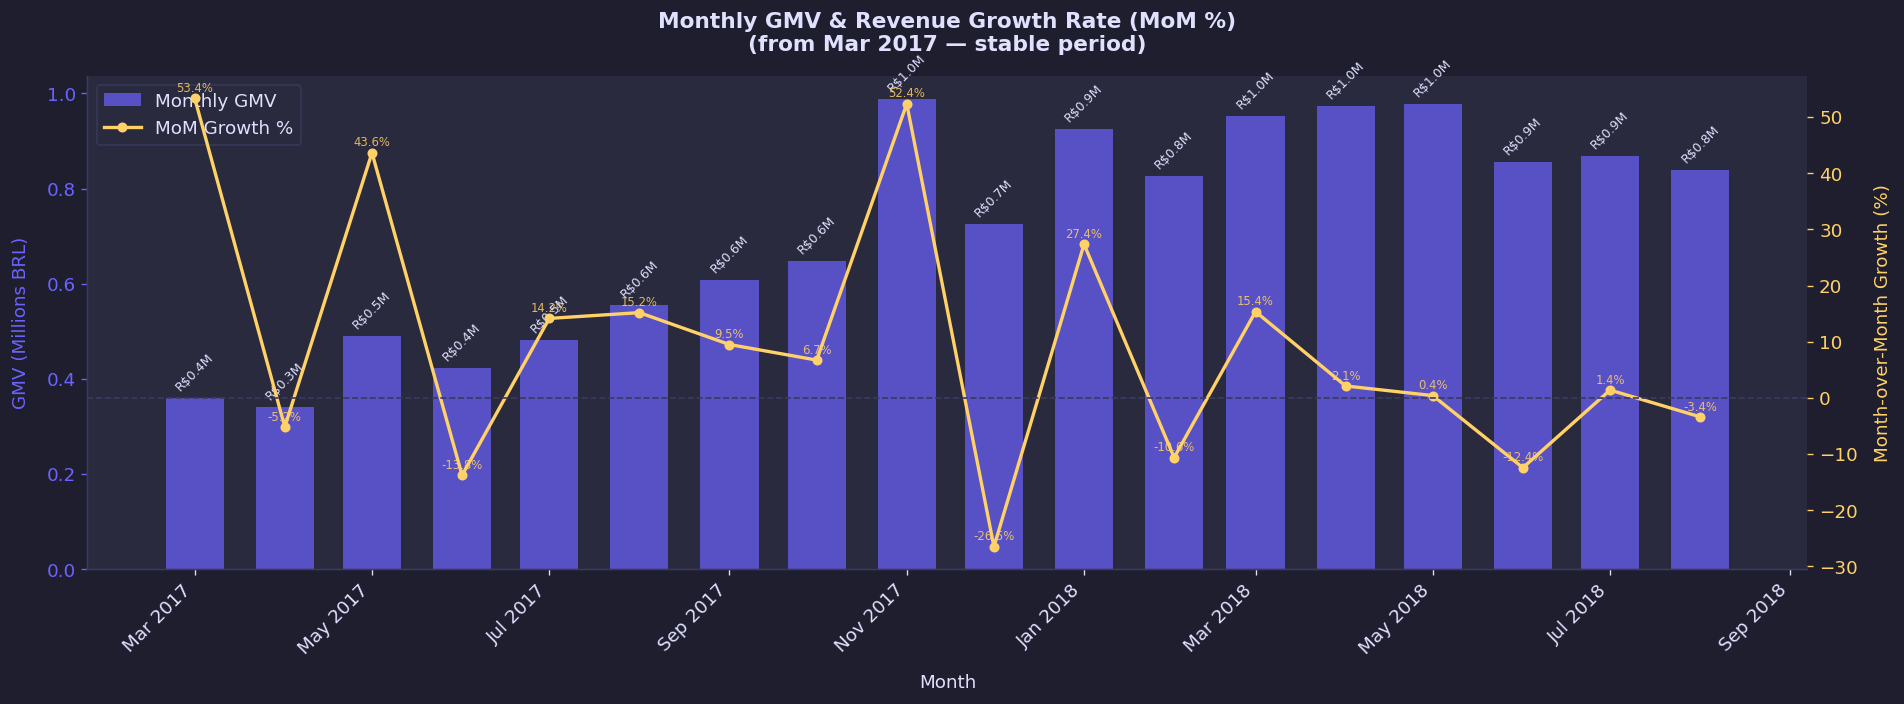


💡 Insight: Peak GMV was R$1.0M in November 2017


In [ ]:
df_q3 = pd.read_sql(q3, engine)
df_q3 = df_q3.dropna()
df_q3['order_month'] = pd.to_datetime(df_q3['order_month'])

# Filter out early outlier months (data ramp-up period)
df_q3 = df_q3[df_q3['order_month'] >= '2017-03-01'].reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)
ax2 = ax1.twinx()

# — GMV Bars —
bars = ax1.bar(df_q3['order_month'], df_q3['total_gmv'] / 1e6,
               width=20, color=PRIMARY, alpha=0.7, label='Monthly GMV')
ax1.set_ylabel('GMV (Millions BRL)', color=PRIMARY, labelpad=10)
ax1.tick_params(axis='y', colors=PRIMARY)
ax1.set_xlabel('Month', labelpad=10)

# Bar Labels
for bar, val in zip(bars, df_q3['total_gmv']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'R${val/1e6:.1f}M',
        ha='center', va='bottom', fontsize=7.5, color=TEXT, rotation=45
    )

# — MoM Growth Line —
ax2.plot(df_q3['order_month'], df_q3['mom_growth_pct'],
         color=YELLOW, linewidth=2, marker='o', markersize=5, label='MoM Growth %')
ax2.axhline(y=0, color=GRID, linestyle='--', linewidth=1)
ax2.set_ylabel('Month-over-Month Growth (%)', color=YELLOW, labelpad=10)
ax2.tick_params(axis='y', colors=YELLOW)

# MoM Labels
for x, y in zip(df_q3['order_month'], df_q3['mom_growth_pct']):
    ax2.text(x, y + 1.2, f'{y:.1f}%', ha='center', fontsize=7,
             color=YELLOW, alpha=0.85)

ax1.set_title('Monthly GMV & Revenue Growth Rate (MoM %)\n(from Mar 2017 — stable period)', pad=15)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           facecolor=SURFACE, edgecolor=GRID, loc='upper left')

plt.tight_layout()
plt.savefig('charts/q3_monthly_revenue_growth.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

peak = df_q3.loc[df_q3['total_gmv'].idxmax()]
print(f"\nInsight: Peak GMV was R${peak['total_gmv']/1e6:.1f}M in {peak['order_month'].strftime('%B %Y')}")

---
## Q4 — Customer Retention Rate

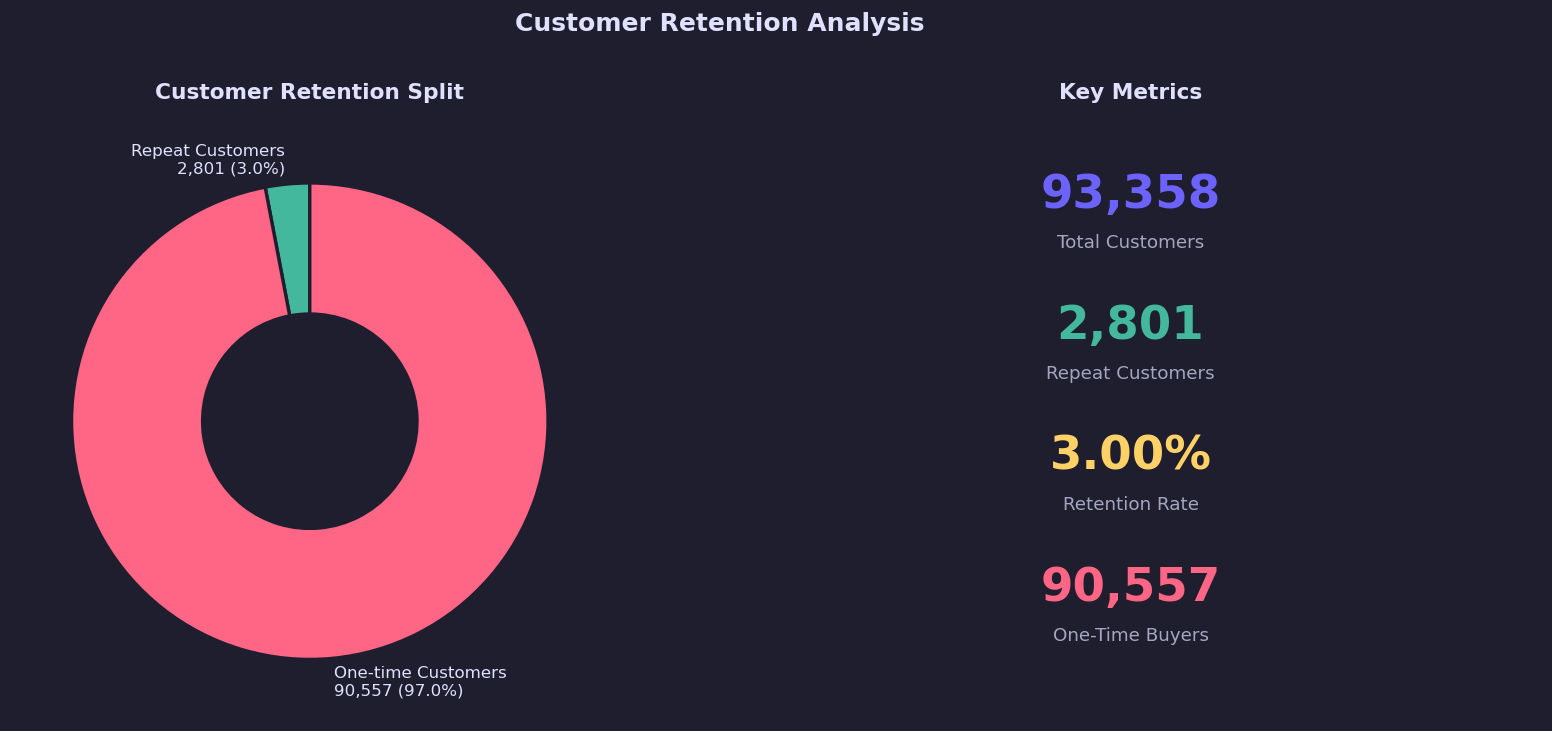


💡 Insight: Only 3.0% of customers placed more than one order.
   This signals a major opportunity for loyalty programs and retention campaigns.


In [ ]:
q4 = """
WITH customer_records AS (
    SELECT 
        ocd.customer_unique_id,
        COUNT(DISTINCT ood.order_id) AS total_orders
    FROM olist_customers_dataset ocd
    JOIN olist_orders_dataset ood ON ocd.customer_id = ood.customer_id
    WHERE ood.order_status = 'delivered'
    GROUP BY ocd.customer_unique_id
)
SELECT
    COUNT(CASE WHEN total_orders >= 2 THEN 1 END) AS repeat_customers,
    COUNT(*)                                        AS total_customers,
    ROUND(COUNT(CASE WHEN total_orders >= 2 THEN 1 END) * 100.0 / COUNT(*), 2) AS retention_pct
FROM customer_records
"""
df_q4 = pd.read_sql(q4, engine)
retention = float(df_q4['retention_pct'].iloc[0])
repeat    = int(df_q4['repeat_customers'].iloc[0])
total     = int(df_q4['total_customers'].iloc[0])
one_time  = total - repeat

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK_BG)

# — Donut Chart —
sizes  = [repeat, one_time]
labels = [f'Repeat Customers\n{repeat:,} ({retention:.1f}%)',
          f'One-time Customers\n{one_time:,} ({100-retention:.1f}%)']
colors = [ACCENT, SECONDARY]
wedges, texts = axes[0].pie(
    sizes, labels=labels, colors=colors,
    startangle=90, wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=2)
)
axes[0].set_title('Customer Retention Split', pad=15)
for text in texts:
    text.set_color(TEXT)
    text.set_fontsize(10)

# — KPI Display —
axes[1].set_facecolor(SURFACE)
axes[1].axis('off')
kpis = [
    ('Total Customers', f'{total:,}', PRIMARY),
    ('Repeat Customers', f'{repeat:,}', ACCENT),
    ('Retention Rate', f'{retention:.2f}%', YELLOW),
    ('One-Time Buyers', f'{one_time:,}', SECONDARY),
]
for i, (label, value, color) in enumerate(kpis):
    y = 0.8 - i * 0.22
    axes[1].text(0.5, y + 0.08, value, ha='center', va='center',
                 fontsize=28, fontweight='bold', color=color, transform=axes[1].transAxes)
    axes[1].text(0.5, y, label, ha='center', va='center',
                 fontsize=11, color=TEXT, alpha=0.7, transform=axes[1].transAxes)
axes[1].set_title('Key Metrics', pad=15)

plt.suptitle('Customer Retention Analysis', fontsize=15, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig('charts/q4_customer_retention.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

print(f"\nInsight: Only {retention:.1f}% of customers placed more than one order.")
print("   This signals a major opportunity for loyalty programs and retention campaigns.")

---
## Q5 - Average Order Value (AOV) by State

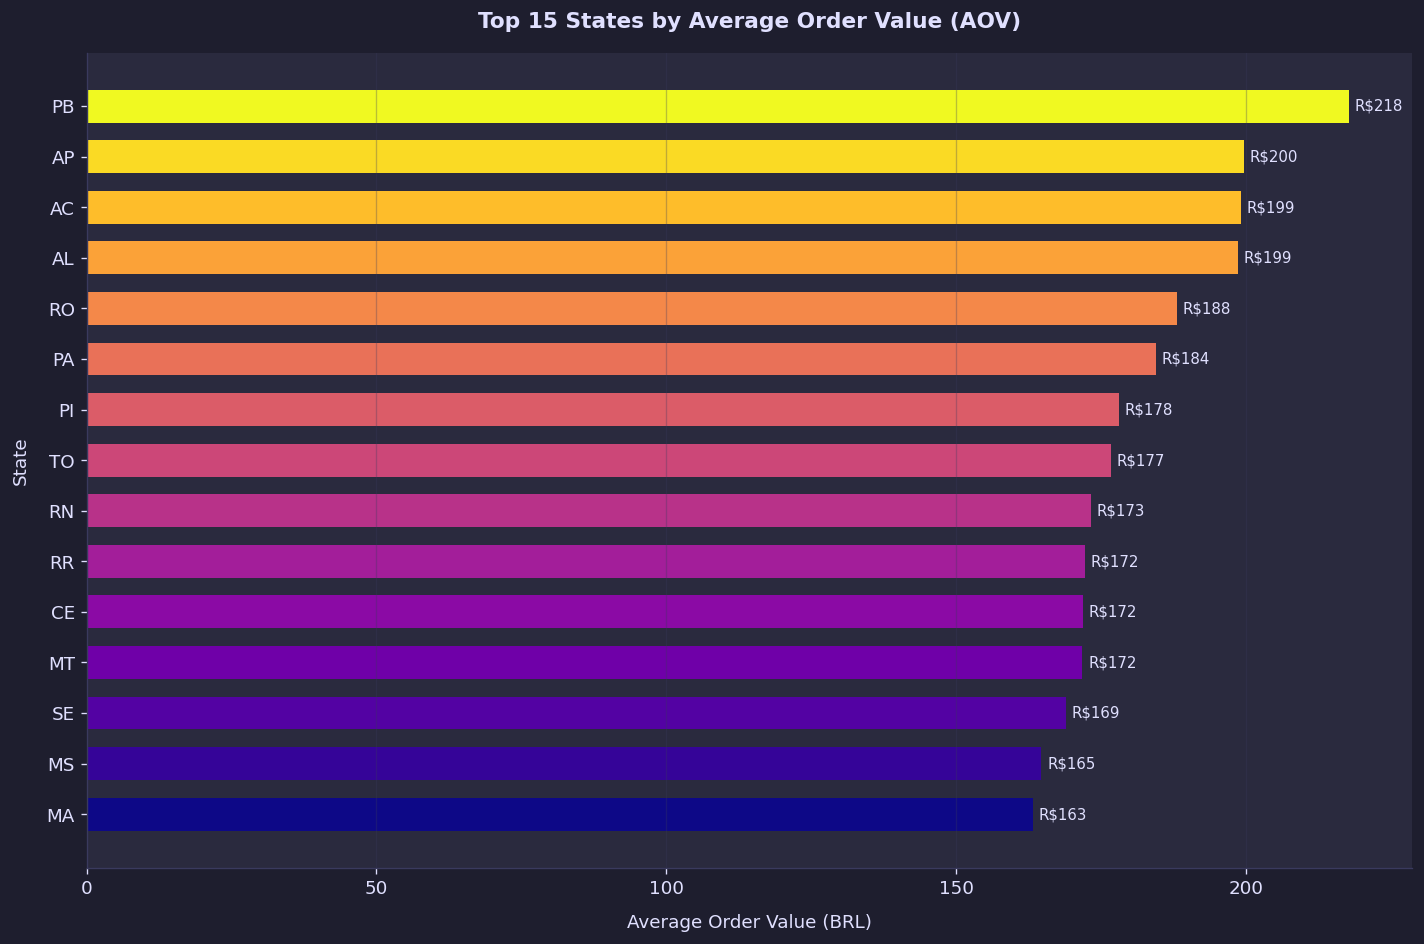


💡 Insight: PB has the highest AOV at R$217.77 per order.


In [ ]:
q5 = """
WITH order_values AS (
    SELECT
        ooid.order_id, 
        ocd.customer_state,
        SUM(ooid.price) AS total_value
    FROM olist_order_items_dataset ooid 
    JOIN olist_orders_dataset ood     ON ooid.order_id  = ood.order_id 
    JOIN olist_customers_dataset ocd  ON ood.customer_id = ocd.customer_id
    WHERE ood.order_status = 'delivered'
    GROUP BY ocd.customer_state, ooid.order_id 
)
SELECT 
    ov.customer_state,
    COUNT(DISTINCT ov.order_id)         AS total_orders,
    ROUND(AVG(ov.total_value), 2)        AS avg_order_value 
FROM order_values ov
GROUP BY ov.customer_state
ORDER BY avg_order_value DESC
"""
df_q5 = pd.read_sql(q5, engine).head(15)
df_q5 = df_q5.sort_values('avg_order_value', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=DARK_BG)

cmap_colors = plt.cm.get_cmap('plasma', len(df_q5))
bar_colors  = [cmap_colors(i) for i in range(len(df_q5))]

bars = ax.barh(df_q5['customer_state'], df_q5['avg_order_value'],
               color=bar_colors, height=0.65, edgecolor='none')

for bar, val, orders in zip(bars, df_q5['avg_order_value'], df_q5['total_orders']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'R${val:.0f}', va='center', fontsize=9, color=TEXT)

ax.set_xlabel('Average Order Value (BRL)', labelpad=10)
ax.set_ylabel('State', labelpad=10)
ax.set_title('Top 15 States by Average Order Value (AOV)', pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/q5_aov_by_state.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

top_state = df_q5.sort_values('avg_order_value', ascending=False).iloc[0]
print(f"\nInsight: {top_state['customer_state']} has the highest AOV at R${top_state['avg_order_value']:.2f} per order.")

---
## Q6 — Payment Method Preference & Installment Behavior

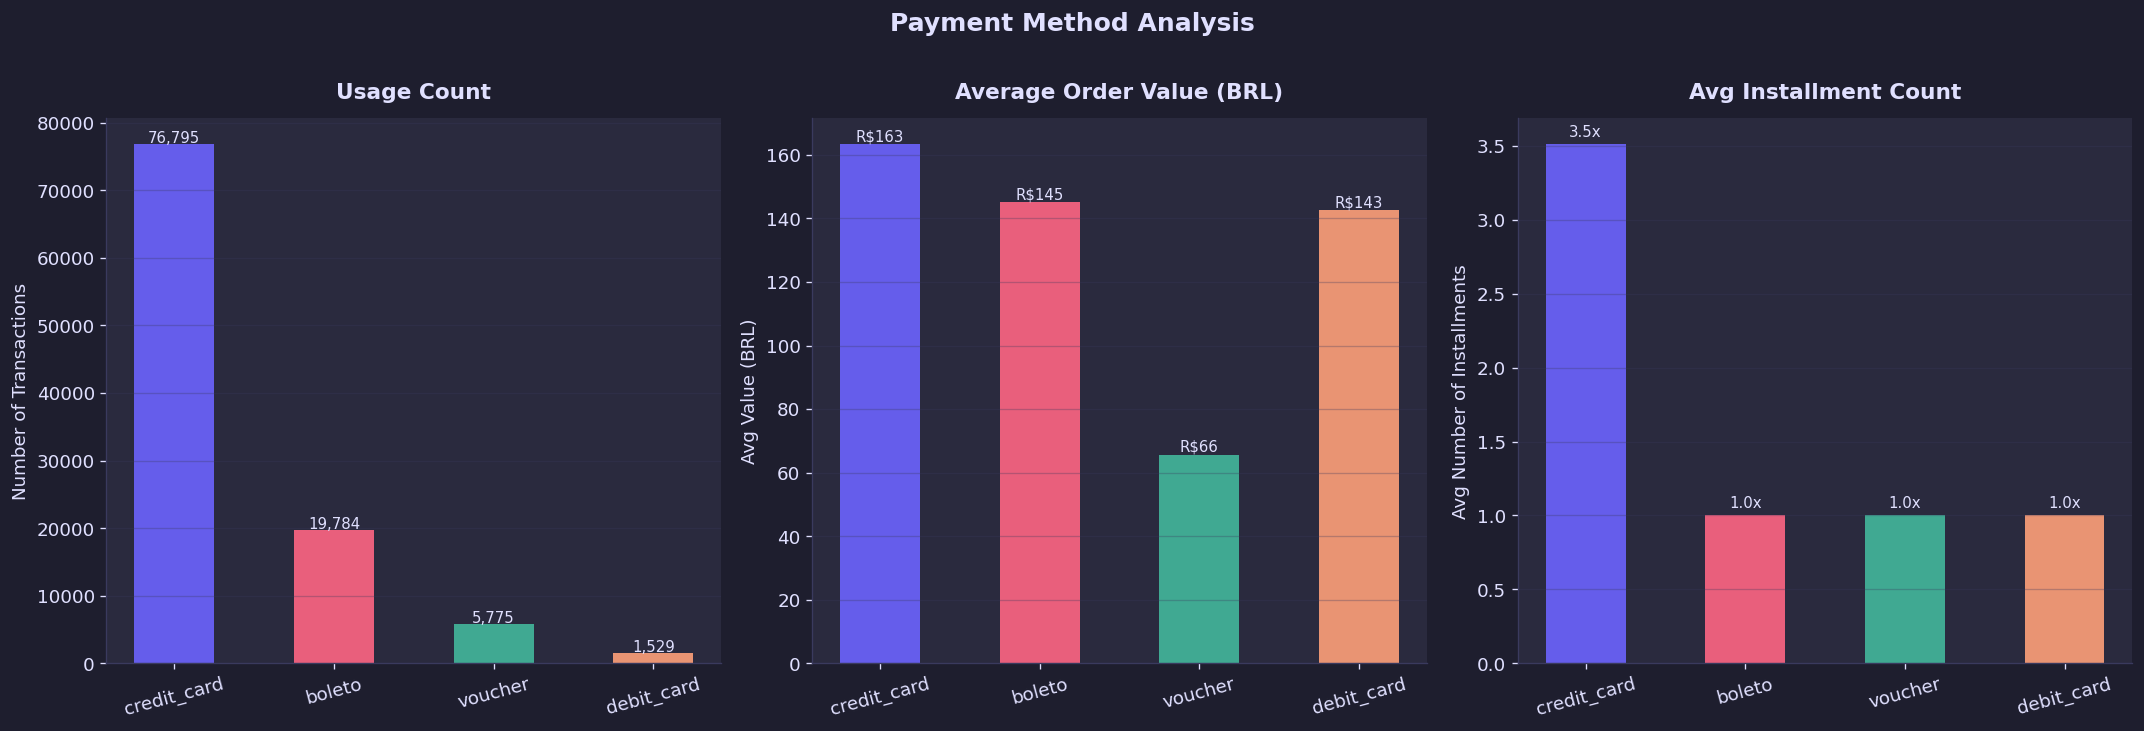


💡 Insight: Credit card dominates with avg 3.5 installments & R$163 avg order value.
   Installment options lower the psychological barrier for high-value purchases.


In [ ]:
q6 = """
SELECT 
    payment_type,
    COUNT(payment_type)                    AS usage_count,
    ROUND(AVG(payment_value), 2)            AS avg_order_value,
    ROUND(AVG(payment_installments), 2)     AS avg_installments 
FROM olist_order_payments_dataset
WHERE payment_type != 'not_defined' 
GROUP BY payment_type
ORDER BY usage_count DESC
"""
df_q6 = pd.read_sql(q6, engine)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=DARK_BG)
fig.suptitle('Payment Method Analysis', fontsize=15, fontweight='bold', color=TEXT, y=1.01)

colors6 = [PRIMARY, SECONDARY, ACCENT, ORANGE]

# — Usage Count —
bars1 = axes[0].bar(df_q6['payment_type'], df_q6['usage_count'],
                    color=colors6[:len(df_q6)], alpha=0.9, width=0.5)
axes[0].set_title('Usage Count', pad=12)
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, df_q6['usage_count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=9, color=TEXT)

# — Avg Order Value —
bars2 = axes[1].bar(df_q6['payment_type'], df_q6['avg_order_value'],
                    color=colors6[:len(df_q6)], alpha=0.9, width=0.5)
axes[1].set_title('Average Order Value (BRL)', pad=12)
axes[1].set_ylabel('Avg Value (BRL)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, df_q6['avg_order_value']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'R${val:.0f}', ha='center', fontsize=9, color=TEXT)

# — Avg Installments —
bars3 = axes[2].bar(df_q6['payment_type'], df_q6['avg_installments'],
                    color=colors6[:len(df_q6)], alpha=0.9, width=0.5)
axes[2].set_title('Avg Installment Count', pad=12)
axes[2].set_ylabel('Avg Number of Installments')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, df_q6['avg_installments']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}x', ha='center', fontsize=9, color=TEXT)

plt.tight_layout()
plt.savefig('charts/q6_payment_behavior.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

cc = df_q6[df_q6['payment_type'] == 'credit_card'].iloc[0]
print(f"\nInsight: Credit card dominates with avg {cc['avg_installments']:.1f} installments & R${cc['avg_order_value']:.0f} avg order value.")
print("   Installment options lower the psychological barrier for high-value purchases.")

---
## Q7 — Average Delivery Time Gap by State

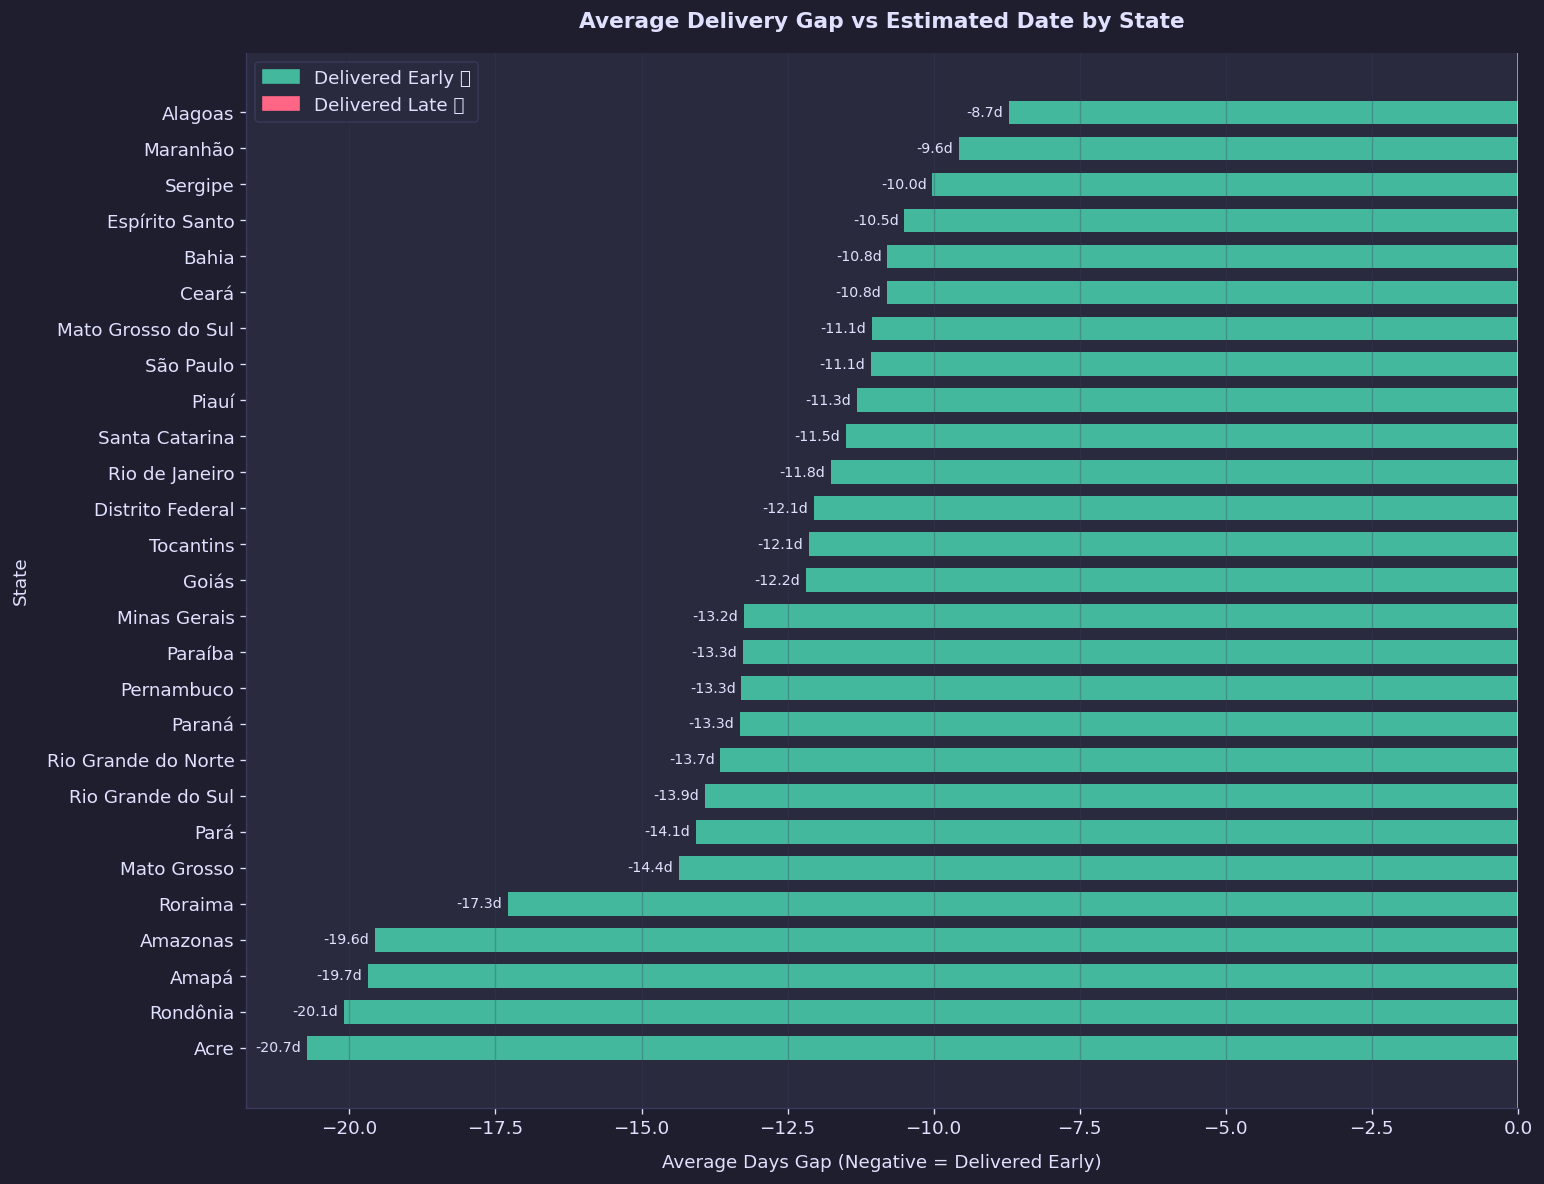


💡 Insight: Most states receive orders ahead of schedule.
   Earliest: Acre at -20.7 days early.


In [ ]:
df_q7 = pd.read_sql(q7, engine)

# Brazilian state code → full name mapping
state_names = {
    'AC': 'Acre',               'AL': 'Alagoas',
    'AP': 'Amapá',              'AM': 'Amazonas',
    'BA': 'Bahia',              'CE': 'Ceará',
    'DF': 'Distrito Federal',   'ES': 'Espírito Santo',
    'GO': 'Goiás',              'MA': 'Maranhão',
    'MT': 'Mato Grosso',        'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',       'PA': 'Pará',
    'PB': 'Paraíba',            'PR': 'Paraná',
    'PE': 'Pernambuco',         'PI': 'Piauí',
    'RJ': 'Rio de Janeiro',     'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',  'RO': 'Rondônia',
    'RR': 'Roraima',            'SC': 'Santa Catarina',
    'SP': 'São Paulo',          'SE': 'Sergipe',
    'TO': 'Tocantins'
}

df_q7['state_name'] = df_q7['customer_state'].map(state_names)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=DARK_BG)

bar_colors = [ACCENT if v <= 0 else SECONDARY for v in df_q7['avg_day_gap']]
bars = ax.barh(df_q7['state_name'], df_q7['avg_day_gap'],
               color=bar_colors, height=0.65, edgecolor='none')
ax.axvline(x=0, color=TEXT, linewidth=1.2, linestyle='-', alpha=0.6)

for bar, val in zip(bars, df_q7['avg_day_gap']):
    x_pos = bar.get_width() + (0.1 if val >= 0 else -0.1)
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}d', va='center', ha=ha, fontsize=8.5, color=TEXT)

ax.set_xlabel('Average Days Gap (Negative = Delivered Early)', labelpad=10)
ax.set_ylabel('State', labelpad=10)
ax.set_title('Average Delivery Gap vs Estimated Date by State', pad=15)
ax.grid(axis='x', alpha=0.3)

early_patch = mpatches.Patch(color=ACCENT,    label='Delivered Early')
late_patch  = mpatches.Patch(color=SECONDARY, label='Delivered Late')
ax.legend(handles=[early_patch, late_patch], facecolor=SURFACE, edgecolor=GRID)

plt.tight_layout()
plt.savefig('charts/q7_delivery_gap_by_state.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

best  = df_q7.sort_values('avg_day_gap').iloc[0]
worst = df_q7.sort_values('avg_day_gap', ascending=False).iloc[0]
print(f"\nInsight: Most states receive orders ahead of schedule.")
print(f"   Earliest: {best['state_name']} at {best['avg_day_gap']:.1f} days early.")
if worst['avg_day_gap'] > 0:
    print(f"   Latest:   {worst['state_name']} at {worst['avg_day_gap']:.1f} days late.")

---
## Q8 — Top Sellers by Revenue + Rating (Combined Rank)

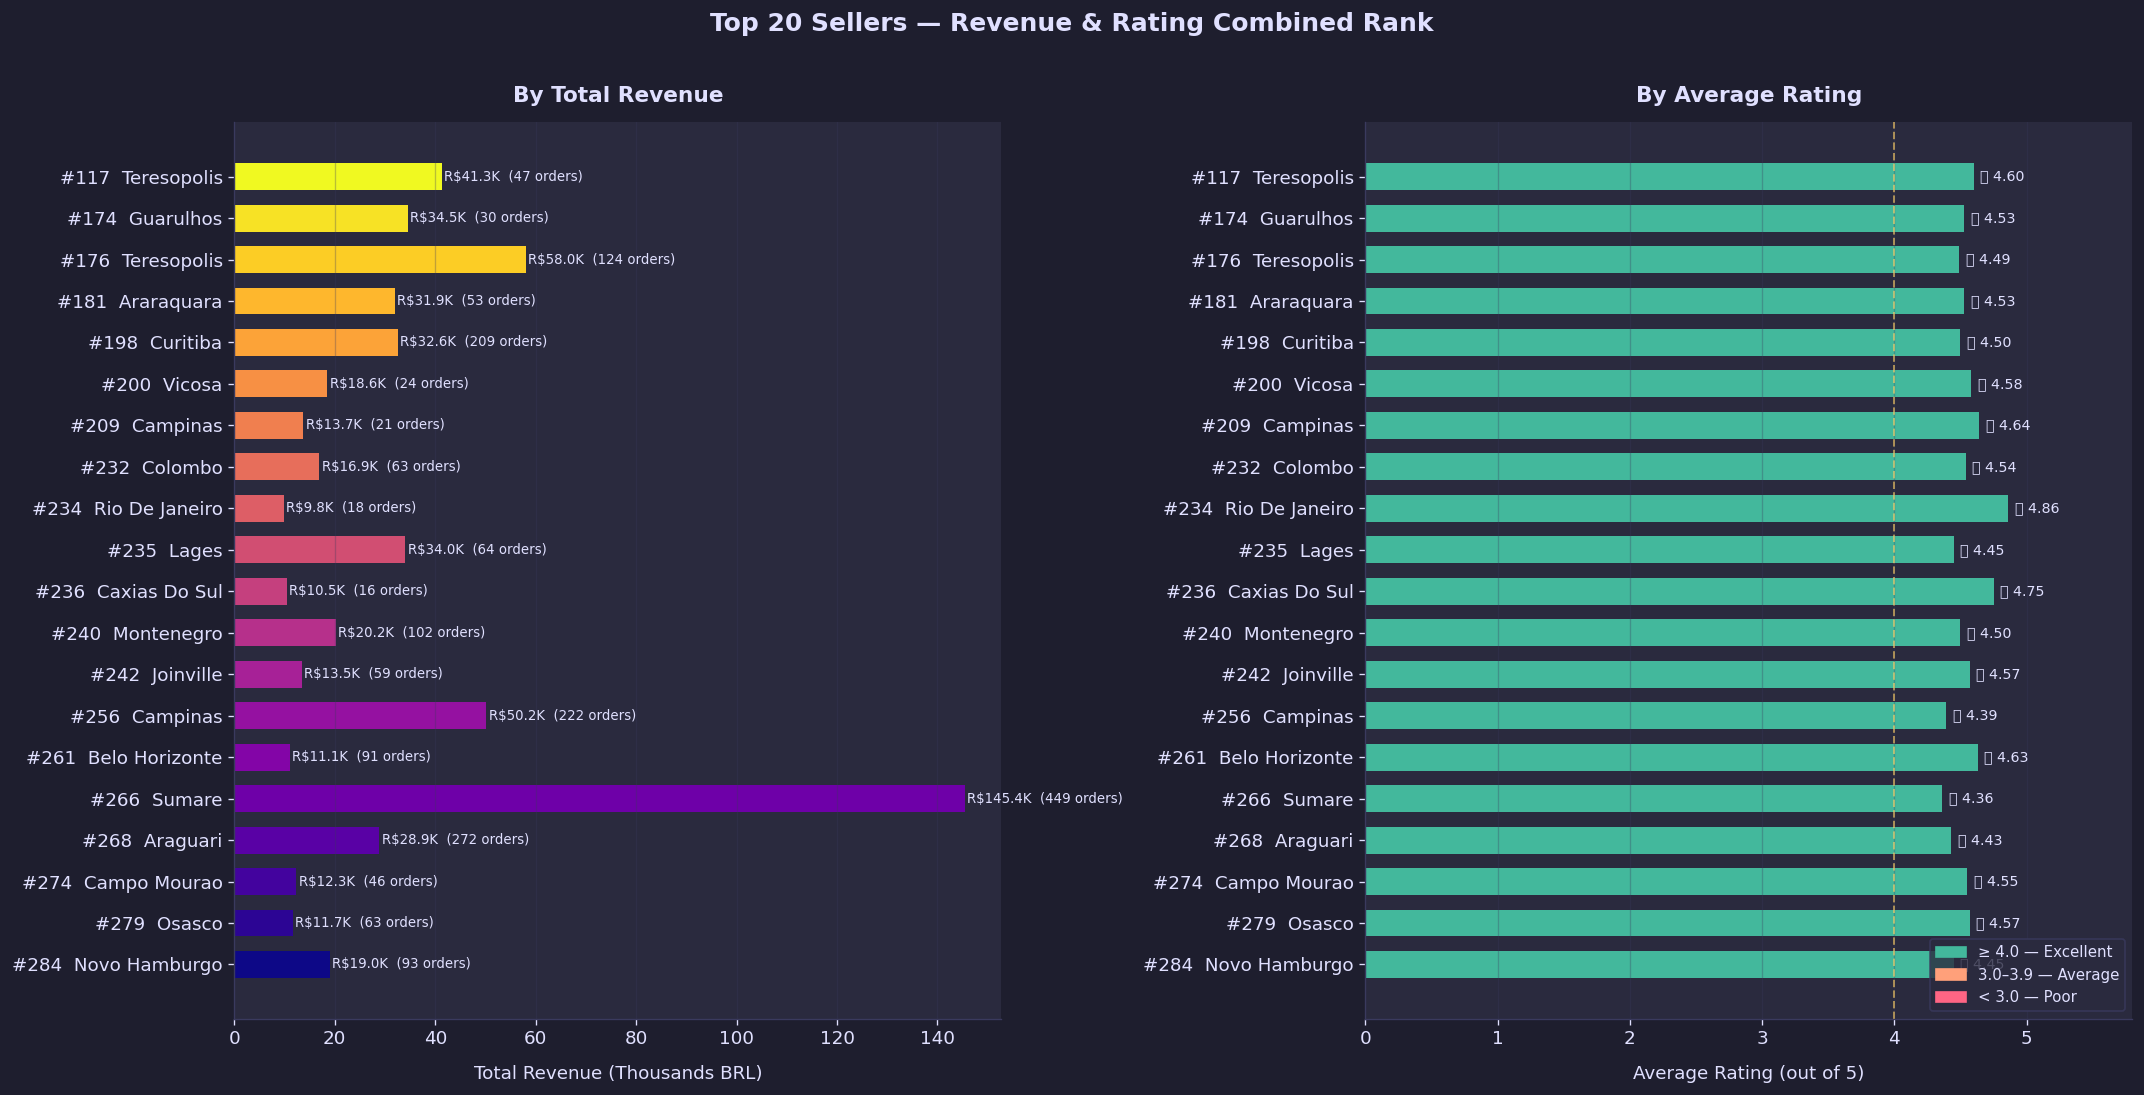


💡 Insight: Best combined seller is from Teresopolis
   Revenue: R$41,300 | Rating: 4.6/5 | Orders: 47


In [ ]:
df_q8 = pd.read_sql(q8, engine)
df_q8 = df_q8.sort_values('combined_rank', ascending=False).reset_index(drop=True)

# Label: Rank + City
df_q8['label'] = df_q8.apply(
    lambda r: f"#{int(r['combined_rank'])}  {r['seller_city'].title()}", axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor=DARK_BG)
fig.suptitle('Top 20 Sellers — Revenue & Rating Combined Rank',
             fontsize=15, fontweight='bold', color=TEXT, y=1.01)

# ── Left: Total Revenue ───────────────────────────────────────────────────────
cmap   = plt.cm.get_cmap('plasma', len(df_q8))
colors = [cmap(i) for i in range(len(df_q8))]

bars1 = axes[0].barh(df_q8['label'], df_q8['total_revenue'] / 1e3,
                     color=colors, height=0.65, edgecolor='none')
axes[0].set_xlabel('Total Revenue (Thousands BRL)', labelpad=10)
axes[0].set_title('By Total Revenue', pad=12)
axes[0].grid(axis='x', alpha=0.3)

for bar, val, orders in zip(bars1, df_q8['total_revenue'], df_q8['total_orders']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'R${val/1e3:.1f}K  ({orders} orders)',
        va='center', fontsize=8, color=TEXT
    )

# ── Right: Average Rating ─────────────────────────────────────────────────────
rating_colors = [ACCENT if r >= 4.0 else ORANGE if r >= 3.0 else SECONDARY
                 for r in df_q8['avg_rating']]

bars2 = axes[1].barh(df_q8['label'], df_q8['avg_rating'],
                     color=rating_colors, height=0.65, edgecolor='none')
axes[1].set_xlabel('Average Rating (out of 5)', labelpad=10)
axes[1].set_title('By Average Rating', pad=12)
axes[1].set_xlim(0, 5.8)
axes[1].axvline(x=4.0, color=YELLOW, linestyle='--', linewidth=1.2,
                alpha=0.6, label='4.0 Threshold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend(facecolor=SURFACE, edgecolor=GRID, fontsize=9)

for bar, val in zip(bars2, df_q8['avg_rating']):
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', fontsize=8.5, color=TEXT
    )

# Color legend for ratings
patch_high = mpatches.Patch(color=ACCENT,    label='≥ 4.0 — Excellent')
patch_mid  = mpatches.Patch(color=ORANGE,    label='3.0–3.9 — Average')
patch_low  = mpatches.Patch(color=SECONDARY, label='< 3.0 — Poor')
axes[1].legend(handles=[patch_high, patch_mid, patch_low],
               facecolor=SURFACE, edgecolor=GRID, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('charts/q8_top_sellers.png', bbox_inches='tight', dpi=150, facecolor=DARK_BG)
plt.show()

best = df_q8.sort_values('combined_rank').iloc[0]
print(f"\nInsight: Best combined seller is from {best['seller_city'].title()}")
print(f"   Revenue: R${best['total_revenue']:,.0f} | Rating: {best['avg_rating']}/5 | Orders: {best['total_orders']}")

---
## Summary Dashboard - Key Insights

| # | Analysis | Key Insight |
|---|----------|-------------|
| 1 | GMV by Category | Health & beauty and watches lead in revenue |
| 2 | Seller Late Delivery | Higher late delivery strongly correlates with lower review scores |
| 3 | Monthly Revenue Growth | Strong overall growth trend with seasonal peaks |
| 4 | Customer Retention | Low repeat purchase rate — opportunity for loyalty programs |
| 5 | AOV by State | Significant regional differences in spending power |
| 6 | Payment Behavior | Credit card dominates; installments drive higher-value purchases |
| 7 | Delivery Gap | Most states receive orders ahead of schedule — conservative estimates |
| 8 | Top Sellers | A small group of sellers drives disproportionate quality + revenue |

---

### Resources
- **Dataset**: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
- **SQL Queries**: `brazillian_e-commerce.sql`
- **Charts**: Saved in `charts/` folder

In [ ]:
# ── EXPORT TO CSV FOR TABLEAU ──────────────────────────────────────────────────
import os
os.makedirs('tableau_data', exist_ok=True)

df_q1.to_csv('tableau_data/gmv_by_category.csv',      index=False)
df_q3.to_csv('tableau_data/monthly_revenue.csv',       index=False)
df_q4_raw = pd.read_sql("""
    SELECT ocd.customer_unique_id,
           COUNT(DISTINCT ood.order_id) AS total_orders
    FROM olist_customers_dataset ocd
    JOIN olist_orders_dataset ood ON ocd.customer_id = ood.customer_id
    WHERE ood.order_status = 'delivered'
    GROUP BY ocd.customer_unique_id
""", engine)
df_q4_raw.to_csv('tableau_data/customer_retention.csv', index=False)
df_q5.to_csv('tableau_data/aov_by_state.csv',          index=False)
df_q6.to_csv('tableau_data/payment_behavior.csv',      index=False)
df_q7.to_csv('tableau_data/delivery_gap.csv',          index=False)
df_q8.to_csv('tableau_data/top_sellers.csv',           index=False)

print("All CSV files exported to tableau_data/ folder!")

✅ All CSV files exported to tableau_data/ folder!
